# Raising buoy

## Imports


:::{.callout-warning}
You need to modify  `ZOOMY_AMREX_HOME` below to point to your local AMReX installation
This test case requires you to have cloned the `ZoomyLab/zoomy-amrex` subrepository `git submodule update --init library/zoomy-amrex`.
This test case requires you to have cloned the `ZoomyLab/data` subrepository `git submodule update --init data`.
:::

In [1]:
import os
os.environ["ZOOMY_AMREX_HOME"] = "/home/is086873/MBD/Git/amrex"


In [2]:
from pathlib import Path
import sys
import rasterio
import numpy as np
from sympy import Matrix
os.environ['ZoomyLog'] = 'Default'
os.environ['ZoomyLogLevel'] = 'INFO'
project_root = Path.cwd().parents[2]  # 0=current, 1=.., 2=../..
sys.path.append(str(project_root))

In [3]:
# | code-fold: true
# | code-summary: "Load packages"
# | output: false

import numpy as np
from sympy import Matrix, Identity

from zoomy_core.model.models.shallow_moments_topo import (
    ShallowMomentsTopo,
    NumericalShallowMomentsTopo,
)
from zoomy_core.model.custom_sympy_functions import conditional


from zoomy_core.fvm.symbolic_numerics import (
    PositiveNonconservativeRusanov,
    PositiveRusanov,
    Rusanov
)


import zoomy_core.model.initial_conditions as IC
import zoomy_core.model.boundary_conditions as BC
from zoomy_core.misc.misc import Zstruct, ZArray, get_main_directory, Settings
import zoomy_core.transformation.to_amrex as trafo
from tutorials.amrex.helper import create_artificial_raster, show_raster, transform_tiff

## Create raster data (initial conditions)

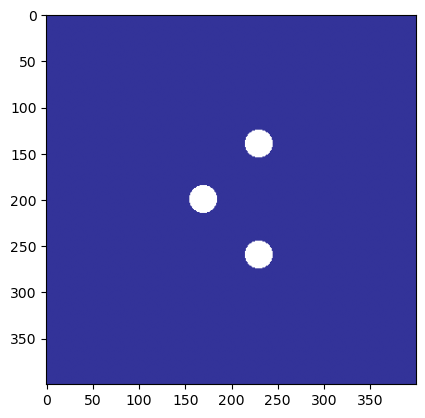

In [4]:
main_dir = get_main_directory()

dem_path = os.path.join(main_dir, 'data/topography_artificial.tif')
ic_water_path = os.path.join(main_dir, 'data/release_artificial.tif')
ic_friction_path = os.path.join(main_dir, 'data/friction_artificial.tif')
N = 200
dx = 0.1
M = N * dx
rBuoy = 1.5
A_buoy = 3.14 * rBuoy**2
M_buoy = 10000
rho = 1000
factor_stress_zz_buoy_on_topography = M_buoy / A_buoy / rho
factor_stress_zz_buoy_on_topography = 0
friction_strength = 1000

def spacial_surface_friction(x,y):
    out = 0. * np.ones_like(x)
    # Xi = []
    # Di = []
    # for i in range(3):
    #     for j in range(10):
    #         Xi.append([i *20 -50, j * 20 -75 ])
    #         Di.append([5])
    Xi = [[3, 6], [-3, 0], [3, -6]]
    Di = [rBuoy, rBuoy, rBuoy]
    for i, xi in enumerate(Xi):
        r = np.sqrt((x-xi[0])**2 + (y-xi[1])**2)
        out += np.where(r < Di[i], friction_strength * np.ones_like(x), 0.0 * np.ones_like(x))
    return out

def buoy_normal_force(x,y):
    return np.where(spacial_surface_friction(x,y) > 0, factor_stress_zz_buoy_on_topography, 0.)

create_artificial_raster(lambda x, y: 5 - buoy_normal_force(x,y), (-M, M, -M, M), dx, ic_water_path)
# create_artificial_raster(lambda x, y: 0 * np.exp(-(x+M)**2/M**2), (-M, M, -M, M), dx, dem_path)
create_artificial_raster(lambda x, y: spacial_surface_friction(x,y), (-M, M, -M, M), dx, ic_friction_path)
create_artificial_raster(lambda x, y: buoy_normal_force(x,y), (-M, M, -M, M), dx, dem_path)


# show_raster(dem_path)
# show_raster(ic_water_path)
show_raster(ic_friction_path)


## Model definition

In [5]:
import sympy as sp
u_mean = 0.0
A = 0.5
h_bc = lambda t:  A * sp.sin(2* 3.14 * t/4) + 5.
u_bc = lambda t: A * sp.sqrt(9.81 / 5) * sp.sin(2 * 3.14 * t / 4)

inflow_dict = {
    1: lambda t, x, dx, q, qaux, p, n: h_bc(t),
    2: lambda t, x, dx, q, qaux, p, n: h_bc(t) * u_bc(t),
}

bcs = BC.BoundaryConditions(
    [
        BC.Extrapolation(tag="N"),
        BC.Extrapolation(tag="S"),
        BC.Lambda(tag="W", prescribe_fields=inflow_dict),
        BC.Extrapolation(tag="E"),
    ]
)


class MyModel(NumericalShallowMomentsTopo):
    
    def flux(self):
        return self._regularize(super().flux())
    
    def nonconservative_matrix(self):
        return self._regularize(super().nonconservative_matrix())
    
    def update_variables(self):
        Q = self.variables
        h = Q[1]
        Qout = ZArray(Q)
        h = conditional(h <= 0, 0, h)
        Qout[1] = h
        eps = self.parameters.eps
        factor = h / (h + eps*100.)
        for i in range(2, self.n_variables):
            Qout[i] *= factor
        return Qout
    
    
    def update_aux_variables(self):
        Q = self.variables
        Qaux = ZArray(self.aux_variables)
        eps = self.parameters.eps
        Qaux[0] = Q[1] / (Q[1]**2 + eps)
        return ZArray(Qaux)
    
    def source(self):
        out = Matrix([0 for i in range(self.n_variables)])
        out += self.newtonian()
        # out += self.slip_mod()
        out += self.slip()
        out += self.surface_friction()
        return out
    
         

level = 4
model = MyModel(
    level=level,
    dimension=2,
    boundary_conditions=bcs,
    parameters=Zstruct(g=9.81, ez=1., nu=0.0001, lamda=1/1000., rho=1000, c_slipmod=1/30, C=300, eps=1e-6, M = 2000),
    aux_variables = ['hinv', 'friction'],
    
)



In [6]:
class Numerics(PositiveRusanov):
    def get_viscosity_identity_flux(self):
        Id = Matrix(Identity(self.model.n_variables))
        lvl = self.model.level
        offset = lvl + 1
        Id = 0 * Id
        Id[1, 1] = 1
        Id[2, 2] = 1
        Id[2 + offset, 2 + offset] = 1
        return ZArray(Id)

    def get_viscosity_identity_fluctuations(self):
        Id = Matrix(Identity(self.model.n_variables))
        Id[0, 0] = 0
        lvl = self.model.level
        offset = lvl + 1
        Id = 0 * Id
        Id[1, 1] = 0
        Id[2, 2] = 0
        Id[2 + offset, 2 + offset] = 0
        return ZArray(Id)


numerics = Numerics(model)


## Print the Model definition

In [7]:
print(model.parameters.keys())
print(model.parameter_values)

['g', 'ez', 'nu', 'lamda', 'rho', 'c_slipmod', 'C', 'eps', 'M']
[9.81000000e+00 1.00000000e+00 1.00000000e-04 1.00000000e-03
 1.00000000e+03 3.33333333e-02 3.00000000e+02 1.00000000e-06
 2.00000000e+03]


Note that this is the numerical model, hence we explicitly use hinv instead of 1/h and apply regularization.
Also note that in the numerical model, the eigenvalues are 'truncated' in the sense that we return 0 eigenvalues for try cells.

In [8]:
model.flux() + model.hydrostatic_pressure()

⎡                  0                                       0                   ⎤
⎢                                                                              ⎥
⎢              hinv⋅q₁⋅q₂                              hinv⋅q₁⋅q₇              ⎥
⎢                                                                              ⎥
⎢       2                      2      2                          2             ⎥
⎢ez⋅g⋅q₁        2      2   hinv ⋅q₁⋅q₃          2            hinv ⋅q₁⋅q₃⋅q₈    ⎥
⎢──────── + hinv ⋅q₁⋅q₂  + ────────────     hinv ⋅q₁⋅q₂⋅q₇ + ──────────────    ⎥
⎢   2                           3                                  3           ⎥
⎢                                                                              ⎥
⎢                 2                             2                2             ⎥
⎢           2⋅hinv ⋅q₁⋅q₂⋅q₃                hinv ⋅q₁⋅q₂⋅q₈ + hinv ⋅q₁⋅q₃⋅q₇    ⎥
⎢                                                                              ⎥
⎢                  2      2 

In [9]:
ZArray([model.nonconservative_matrix()[:,:,0], model.nonconservative_matrix()[:,:,1]])


⎡⎡0  0  0     0           0            0            0       0  0  0  0  0⎤  ⎡0 ↪
⎢⎢                                                                       ⎥  ⎢  ↪
⎢⎢0  0  0     0           0            0            0       0  0  0  0  0⎥  ⎢0 ↪
⎢⎢                                                                       ⎥  ⎢  ↪
⎢⎢0  0  0     0           0            0            0       0  0  0  0  0⎥  ⎢0 ↪
⎢⎢                                                                       ⎥  ⎢  ↪
⎢⎢                   -2⋅hinv⋅q₃                                          ⎥  ⎢  ↪
⎢⎢0  0  0  -hinv⋅q₂  ───────────       0            0       0  0  0  0  0⎥  ⎢0 ↪
⎢⎢                        5                                              ⎥  ⎢  ↪
⎢⎢                                                                       ⎥  ⎢  ↪
⎢⎢                                -5⋅hinv⋅q₃                             ⎥  ⎢  ↪
⎢⎢0  0  0     0       -hinv⋅q₂    ───────────       0       0  0  0  0  0⎥  ⎢0 ↪
⎢⎢                          

In [10]:
model.source()


⎡                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                      5.0⋅friction⋅(hinv⋅q₂ - 1.0⋅hinv⋅q₃ + 1.0⋅hinv⋅q₄ - 1.0 ↪
⎢                    - ─────────────────────────────────────────────────────── ↪
⎢                                                            ρ                 ↪
⎢                                                                              ↪
⎢     15.0⋅friction⋅(hinv⋅q₂ - 1.0⋅hinv⋅q₃ + 1.0⋅hinv⋅q₄ - 1.0⋅hinv⋅q₅ + 1.0⋅h ↪
⎢     ──────────────────────────────────────────────────────────────────────── ↪
⎢                                            ρ                                 ↪
⎢                                                                              ↪
⎢      25.0⋅friction⋅(hinv⋅q

In [11]:
model.functions.eigenvalues.definition

⎡                                                                              ↪
⎢                                                                              ↪
⎢                                        ⎛          n₀⋅q₂ + n₁⋅q₄   ⎞          ↪
⎢conditional(q₁ > eps, 0, 0)  conditional⎜q₁ > eps, ─────────────, 0⎟  conditi ↪
⎣                                        ⎝               q₁         ⎠          ↪

↪     ⎛                             __________________________________________ ↪
↪     ⎜                            ╱        2   3          2   3     2   2     ↪
↪     ⎜          n₀⋅q₂ + n₁⋅q₄ - ╲╱  ez⋅g⋅n₀ ⋅q₁  + ez⋅g⋅n₁ ⋅q₁  + n₀ ⋅q₃  + 2 ↪
↪ onal⎜q₁ > eps, ───────────────────────────────────────────────────────────── ↪
↪     ⎝                                                   q₁                   ↪

↪ _______________________   ⎞             ⎛                             ______ ↪
↪                  2   2    ⎟             ⎜                            ╱       ↪
↪ ⋅n₀⋅n₁⋅q₃⋅q₅ + n₁ ⋅q₅   

## Code transformation and AMReX compilation

if you want to "clean" and compile from scratch, Comment in "make clean" two cells below.

In [12]:

import shutil
from pathlib import Path
settings = Settings(name="ShallowMoments", output=Zstruct(directory=f"outputs/amrex_{level}"))
source_dir = Path(os.path.join(main_dir, 'library/zoomy_amrex/Exec'))
output_dir = Path(os.path.join(main_dir, settings.output.directory))

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

trafo.AmrexModel.write_code(model, settings)
trafo.AmrexNumerics.write_code(numerics, settings)

# trafo.write_code(model, settings)
main_dir = get_main_directory()
os.environ['ZOOMY_AMREX_MODEL'] = os.path.join(main_dir, os.path.join(settings.output.directory, '.amrex_interface'))

2026-03-10 13:20:52.411 | WARNING  | zoomy_core.misc.misc:__init__:412 - No 'filename' attribute found in Settings.output Zstruct. Default: 'simulation'
2026-03-10 13:20:52.411 | WARNING  | zoomy_core.misc.misc:__init__:412 - No 'clean_directory' attribute found in Settings.output Zstruct. Default: 'False'
2026-03-10 13:20:52.411 | WARNING  | zoomy_core.misc.misc:__init__:412 - No 'snapshots' attribute found in Settings.output Zstruct. Default: '2'


### What have we gained? 

* A C++ file containing the translation of our symbolical PDE model 
* A C++ file containing the translatoin of our numerical Riemann solver, including Wet-dry front treatment. 

Let's have a look at the code now!

#### Model.H

In [13]:
main_dir = get_main_directory()
path = os.path.join(main_dir, os.path.join(settings.output.directory, '.amrex_interface/Model.H'))
with open(path, "r") as f:
    print(f.read())

#pragma once
#include <AMReX_Array4.H>
#include <AMReX_Vector.H>
#include <AMReX_SmallMatrix.H>

#include <vector>
#include <string>
#include <algorithm>

#ifdef __CUDACC__
#define PORTABLE_FN __host__ __device__
#else
#define PORTABLE_FN
#endif


struct Model {
    using T = amrex::Real;
    static constexpr int n_dof_q    = 12;
    static constexpr int n_dof_qaux = 2;
    static constexpr int n_parameters = 9;
    static constexpr int dimension  = 2;
    static constexpr int n_boundary_tags = 4;
    static const std::vector<std::string> get_boundary_tags() { return { "E", "N", "S", "W" }; }
    static const std::vector<std::string> parameter_names() { return { "g", "ez", "nu", "lamda", "rho", "c_slipmod", "C", "eps", "M" }; }
    static const std::vector<T> default_parameters() { return { 9.81, 1.0, 0.0001, 0.001, 1000.0, 0.03333333333333333, 300.0, 1e-06, 2000.0 }; }

    AMREX_GPU_HOST_DEVICE AMREX_FORCE_INLINE
    static amrex::SmallMatrix<amrex::Real,24,1> flux(
        amrex::Sm

#### Numerics.H

In [14]:
main_dir = get_main_directory()
path = os.path.join(main_dir, os.path.join(settings.output.directory, '.amrex_interface/Numerics.H'))
with open(path, "r") as f:
    print(f.read())

#pragma once
#include <AMReX_Array4.H>
#include <AMReX_Vector.H>
#include <AMReX_SmallMatrix.H>
#include "Model.H"

#include <vector>
#include <algorithm>

#ifdef __CUDACC__
#define PORTABLE_FN __host__ __device__
#else
#define PORTABLE_FN
#endif


struct Numerics {
    using T = amrex::Real;
    static constexpr int n_dof_q = 12;

    AMREX_GPU_HOST_DEVICE AMREX_FORCE_INLINE
    static amrex::SmallMatrix<amrex::Real,12,1> numerical_flux(
        amrex::SmallMatrix<amrex::Real,12,1> const& Q_minus,
        amrex::SmallMatrix<amrex::Real,12,1> const& Q_plus,
        amrex::SmallMatrix<amrex::Real,2,1> const& Qaux_minus,
        amrex::SmallMatrix<amrex::Real,2,1> const& Qaux_plus,
        amrex::SmallMatrix<amrex::Real,9,1> const& p,
        amrex::SmallMatrix<amrex::Real,2,1> const& n) noexcept
    {
    amrex::Real t0 = amrex::max(Q_minus(0, 0), Q_plus(0, 0));
    amrex::Real t1 = -t0;
    amrex::Real t2 = amrex::max(0.0, Q_minus(0, 0) + Q_minus(1, 0) + t1);
    amrex::Real t3 = t2/am

#### Compile

In [15]:
import subprocess

base = os.path.join(main_dir, "library/zoomy_amrex/")
cmds = [
    f"cp ../../{settings.output.directory}/.amrex_interface/Model.H ./Source/Model.H",
    f"cp ../../{settings.output.directory}/.amrex_interface/Numerics.H ./Source/Numerics.H",
    "source setup.sh",
    "cd Exec",
    #"make clean",
    "make",
]

subprocess.run(" && ".join(cmds), shell=True, executable="/bin/zsh", cwd=base)


[WARN] OpenMPI's default binding is set to OFF, you can override this
[INFO] Module foss/2024a loaded.
[INFO] Module Python/3.12.3 loaded.
fatal: not a git repository (or any parent up to mount point /rwthfs/rz/cluster/home)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


Loading /home/is086873/MBD/Git/amrex/Tools/GNUMake/comps/gnu.mak...
Loading /home/is086873/MBD/Git/amrex/Tools/GNUMake/sites/Make.unknown...
Compiling write_plotfiles.cpp ...
mpicxx -MMD -MP -Werror=return-type -gdwarf-4 -O3 -finline-limit=43210 -std=c++17  -pthread    -DBL_USE_MPI -DAMREX_USE_MPI -DAMREX_GPU_MAX_THREADS=0 -DBL_SPACEDIM=3 -DAMREX_SPACEDIM=3 -DBL_FORT_USE_UNDERSCORE -DAMREX_FORT_USE_UNDERSCORE -DBL_Linux -DAMREX_Linux -DNDEBUG -DOMPI_SKIP_MPICXX -Itmp_build_dir/s/3d.gnu.MPI.EXE -I. -I../Source -I/rwthfs/rz/cluster/home/is086873/Git/Zoomy/outputs/amrex_4/.amrex_interface -I/home/is086873/MBD/Git/amrex/Src/Base -I/home/is086873/MBD/Git/amrex/Src/Base/Parser  -I/cvmfs/software.hpc.rwth.de/Linux/RH9/x86_64/intel/sapphirerapids/software/OpenMPI/5.0.3-GCC-13.3.0/include -c ../Source/write_plotfiles.cpp -o tmp_build_dir/o/3d.gnu.MPI.EXE/write_plotfiles.o
Compiling main.cpp ...
mpicxx -MMD -MP -Werror=return-type -gdwarf-4 -O3 -finline-limit=43210 -std=c++17  -pthread    -DBL_U

CompletedProcess(args='cp ../../outputs/amrex_4/.amrex_interface/Model.H ./Source/Model.H && cp ../../outputs/amrex_4/.amrex_interface/Numerics.H ./Source/Numerics.H && source setup.sh && cd Exec && make', returncode=0)

## Prepare raster data for AMReX

... and copy stuff to the output directory ...

In [16]:


output_dir.mkdir(parents=True, exist_ok=True)  # make sure output folder exists

for item in source_dir.iterdir():
    dest = output_dir / item.name
    if item.is_dir():
        shutil.copytree(item, dest, dirs_exist_ok=True)
    else:
        shutil.copy2(item, dest)
        
shutil.copy(dem_path, output_dir)
shutil.copy(ic_water_path, output_dir)

print("The simulation output will be written to: ", output_dir)

from zoomy_amrex.preprocess_rasterdata import preprocess
preprocess(os.path.join(output_dir, 'inputs'), [('dem', dem_path), ('release', ic_water_path), ('friction', ic_friction_path)])


The simulation output will be written to:  /rwthfs/rz/cluster/home/is086873/Git/Zoomy/outputs/amrex_4
✓ raw files created: topography_artificial.raw, release_artificial.raw, friction_artificial.raw
✓ inputs updated → /rwthfs/rz/cluster/home/is086873/Git/Zoomy/outputs/amrex_4/inputs


## Do the Simulation

run in the notebook or as a batch job

In [17]:
run_in_notebook = True

In [18]:
if (run_in_notebook):
    base = os.path.join(main_dir, 'library/zoomy_amrex/')
    cmds = [
        "source setup.sh",
        f"cd ../../{settings.output.directory}",
        "./clean.sh",
        "mpiexec -np 4 ./main3d.gnu.MPI.ex inputs",
    ]

    subprocess.run("\n".join(cmds), shell=True, executable="/bin/zsh", cwd=base)
else:
    base = os.path.join(main_dir, 'library/zoomy_amrex/')
    cmds = [
        "source setup.sh",
        f"cd ../../{settings.output.directory}",
        "./clean.sh",
        "sbatch batch.sh < inputs",
    ]

    subprocess.run("\n".join(cmds), shell=True, executable="/bin/zsh", cwd=base)

        

[WARN] OpenMPI's default binding is set to OFF, you can override this
[INFO] Module foss/2024a loaded.
[INFO] Module Python/3.12.3 loaded.
./clean.sh:3: no matches found: plt*
./clean.sh:4: no matches found: output*.txt
./clean.sh:5: no matches found: Backtrace*


Initializing AMReX (25.03)...
MPI initialized with 4 MPI processes
MPI initialized with thread support level 0
AMReX (25.03) initialized
✓ loaded '/rwthfs/rz/cluster/home/is086873/Git/Zoomy/data/release_artificial.raw' into component 1 (400×400)
✓ loaded '/rwthfs/rz/cluster/home/is086873/Git/Zoomy/data/topography_artificial.raw' into component 0 (400×400)
✓ loaded '/rwthfs/rz/cluster/home/is086873/Git/Zoomy/data/friction_artificial.raw' into component 1 (400×400)
Step 0 dt: 0.006425294053 time: 0s in 0.014210693s
Step 1 dt: 0.006425294053 time: 0.006425294053s in 0.014248884s
Step 2 dt: 0.006420915765 time: 0.01285058811s in 0.013223138s
Step 3 dt: 0.006414144211 time: 0.01927150387s in 0.013476408s
Step 4 dt: 0.006406081141 time: 0.02568564808s in 0.014621756s
Step 5 dt: 0.006397333211 time: 0.03209172922s in 0.014456194s
Step 6 dt: 0.006388233038 time: 0.03848906243s in 0.014111041s
Step 7 dt: 0.006378962759 time: 0.04487729547s in 0.014387647s
Step 8 dt: 0.006369622194 time: 0.05125